# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import cftime
import scipy
import cartopy
import pandas as pd
from scipy.stats import ttest_ind
from cartopy.util import add_cyclic_point
import cartopy.crs as ccrs
#from eofs.xarray import Eof 

In [2]:
import sys
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

In [3]:
from load_ensembles import *
from load_gridcell_areas import *
from plotting_settings import *
from FDR_analysis import *

# Load data

In [4]:
path_in='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'

In [5]:
ds = xr.open_dataset(path_in+'delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
pvals=xr.open_dataset(path_in+'pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['pval']
ds_ref=xr.open_dataset(path_in+'ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']

In [6]:
landweights=landweights.reindex_like(ds_ref, method='nearest',tolerance=0.05)

In [7]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/EOFs/'
eofs=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_EOFs.nc')
pcs=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_PCs.nc')
var_explained=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_varianceFraction.nc')

# Do some calculations

In [8]:
pct_change=(ds/ds_ref)*100
sig_pct_change=pct_change.where(pvals<=0.05)
sig_pct_change=sig_pct_change.where(~np.isnan(sig_pct_change),0)

pct_change_range=(pct_change).max(dim='ensemble_key')-(pct_change).min(dim='ensemble_key')
pct_change_range=pct_change_range.where(~np.isnan(pct_change_range),0).where(landweights>0)

In [9]:
# Global averages
ds_global=(ds*landweights).mean(dim=['lat','lon'])
ref_global=(ds_ref*landweights).mean(dim=['lat','lon'])
ds_delta_global_pct=(ds_global)*100/ref_global

# Global averages
pct_range=(np.abs(pct_change)*landweights).mean(dim=['lat','lon'])

# Figure 3a

Lorenz, R., A. J. Pitman, and S. A. Sisson (2016), Does Amazonian deforestation cause global effects; can we be sure?, J. Geophys. Res. Atmos., 121, 5567–5584, doi:10.1002/2015JD024357.

False Discovery Rate. The false discovery rate (FDR) identifies locally significant tests by controlling the expected proportion of rejected local null hypotheses that are actually true. Hence, field significance is declared if at least one local null hypotheses is rejected according to this criterion at the level 𝛼global [Wilks, 2006]. We reject a local test with p value plocal if plocal is no greater than p_FDR
where p(j) denotes the jth smallest (out of K) local p values. The global null hypothesis is rejected if any of the local p values satisfies the bracketed condition above. Despite being more liberal than the Monte Carlo counting method [Livezey and Chen, 1983] and Walker’s test, the FDR has the advantage of not only testing for field significance but also identifying the local grid points with local p values which are small enough to reject the global null hypothesis. Hence, the FDR gives not only a yes (field significant) or no (not significant) answer like Walker’s test but also spatially identifies those significant grid points which cause the global null hypothesis to be rejected (if it is rejected).

In [10]:
alpha_global=0.05#05
K=(landweights.values.flatten()>0).sum()

significant_changes=np.zeros(np.shape(pvals))
significant_changes[:]=np.nan
significant_changes_xr=xr.DataArray(significant_changes,
                                    dims=("lat", "lon", "ensemble_key"),
    coords=[('lat',pvals.lat),
            ('lon',pvals.lon),
           ('ensemble_key',pvals.ensemble_key)])

/glade/u/ssg/ch/usr/jupyterhub/envs/cmip6-201910a/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in greater
  


In [11]:
significant_changes_xr=calculate_sig_changes_FDR(pvals, 
                          K=(landweights.values.flatten()>0).sum())

/glade/u/ssg/ch/usr/jupyterhub/envs/cmip6-201910a/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in greater
  


In [12]:
mapdata=pct_change_range
#sigmask=((pvals>0.05).sum(dim=['ensemble_key'])>=31)
sigmask=((significant_changes_xr<1).sum(dim='ensemble_key')>=31)

In [16]:
plt.rcParams.update({'hatch.color': 'black'})

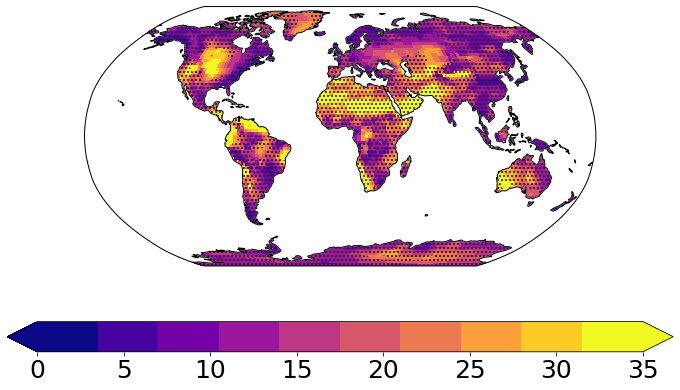

In [18]:
plt.rcParams.update({'font.size': 25})
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

cyclic_data, cyclic_lons = add_cyclic_point(mapdata, coord=mapdata.lon)

plt.pcolormesh(cyclic_lons, mapdata.lat, #contourf
                   cyclic_data, 
                   cmap=plt.cm.get_cmap("plasma",10), vmin=0, vmax=35,#levels=np.arange(-100,100),
                   transform=ccrs.PlateCarree())#, extend='both')
plt.colorbar(extend='both', orientation='horizontal')#, ticks=np.arange(-0.025, 0.030, 0.005))

cyclic_data_mask, cyclic_lons_mask = add_cyclic_point(sigmask, coord=sigmask.lon)
ax.contourf(
            cyclic_lons_mask, sigmask.lat, cyclic_data_mask,
            transform=ccrs.PlateCarree(),
            colors='none',
            levels=[0.5, 1.5],
            hatches=['...'])
        
plt.tight_layout()
ax.add_feature(cartopy.feature.OCEAN, facecolor='white', zorder=1)
ax.coastlines()
plt.savefig('../Figures/Figure_3a.pdf')

# Figure 3b

In [25]:
plt.rcParams.update({'hatch.color': 'black'})

In [20]:
mod_factor=np.std(pcs.pcs[:,0])
pcs_mod=pcs.pcs/mod_factor
eofs_mod=eofs.eofs*mod_factor
mapdata=eofs_mod[:,:,0]

crosswalk['PREC_mode0']=np.nan
for i, key in enumerate(ds.ensemble_key.values):
    crosswalk.loc[crosswalk.Key_short==key,['PREC_mode0']]=pcs_mod[:,0].values[i]

In [21]:
(mapdata*landweights).mean(dim=['lat','lon'])

<xarray.DataArray ()>
array(11.09721849)
Coordinates:
    mode     int64 0

In [22]:
num_sig_ensemble_members=(significant_changes_xr<1).sum(dim='ensemble_key')

In [23]:
maskedarray=np.ma.masked_less(num_sig_ensemble_members, 30)

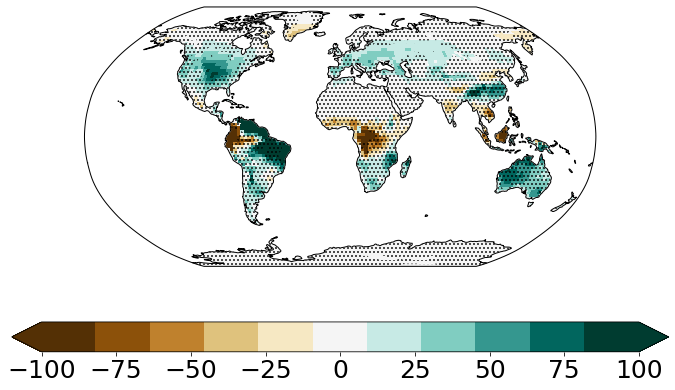

In [26]:
plt.rcParams.update({'font.size': 25})
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

cyclic_data, cyclic_lons = add_cyclic_point(mapdata, coord=mapdata.lon)

plt.pcolormesh(cyclic_lons, mapdata.lat, #contourf
                   cyclic_data, 
                   cmap=plt.cm.get_cmap("BrBG",11), vmin=-100, vmax=100,#levels=np.arange(-100,100),
                   transform=ccrs.PlateCarree())#, extend='both')
plt.colorbar(extend='both', orientation='horizontal')#, ticks=np.arange(-0.025, 0.030, 0.005))

cyclic_data_mask, cyclic_lons_mask = add_cyclic_point(sigmask, coord=sigmask.lon)
cs=ax.contourf(
            cyclic_lons_mask, sigmask.lat, cyclic_data_mask,
            transform=ccrs.PlateCarree(),
            colors='none',
            levels=[0.5, 1.5],
            hatches=['...'])
#for i, collection in enumerate(cs.collections[0:1]):
#cs.collections[0].set_markercolor('gray')
        
plt.tight_layout()
ax.add_feature(cartopy.feature.OCEAN, facecolor='white', zorder=1)
ax.coastlines()
plt.savefig('../Figures/Figure_3b.pdf')

# Figure 3c

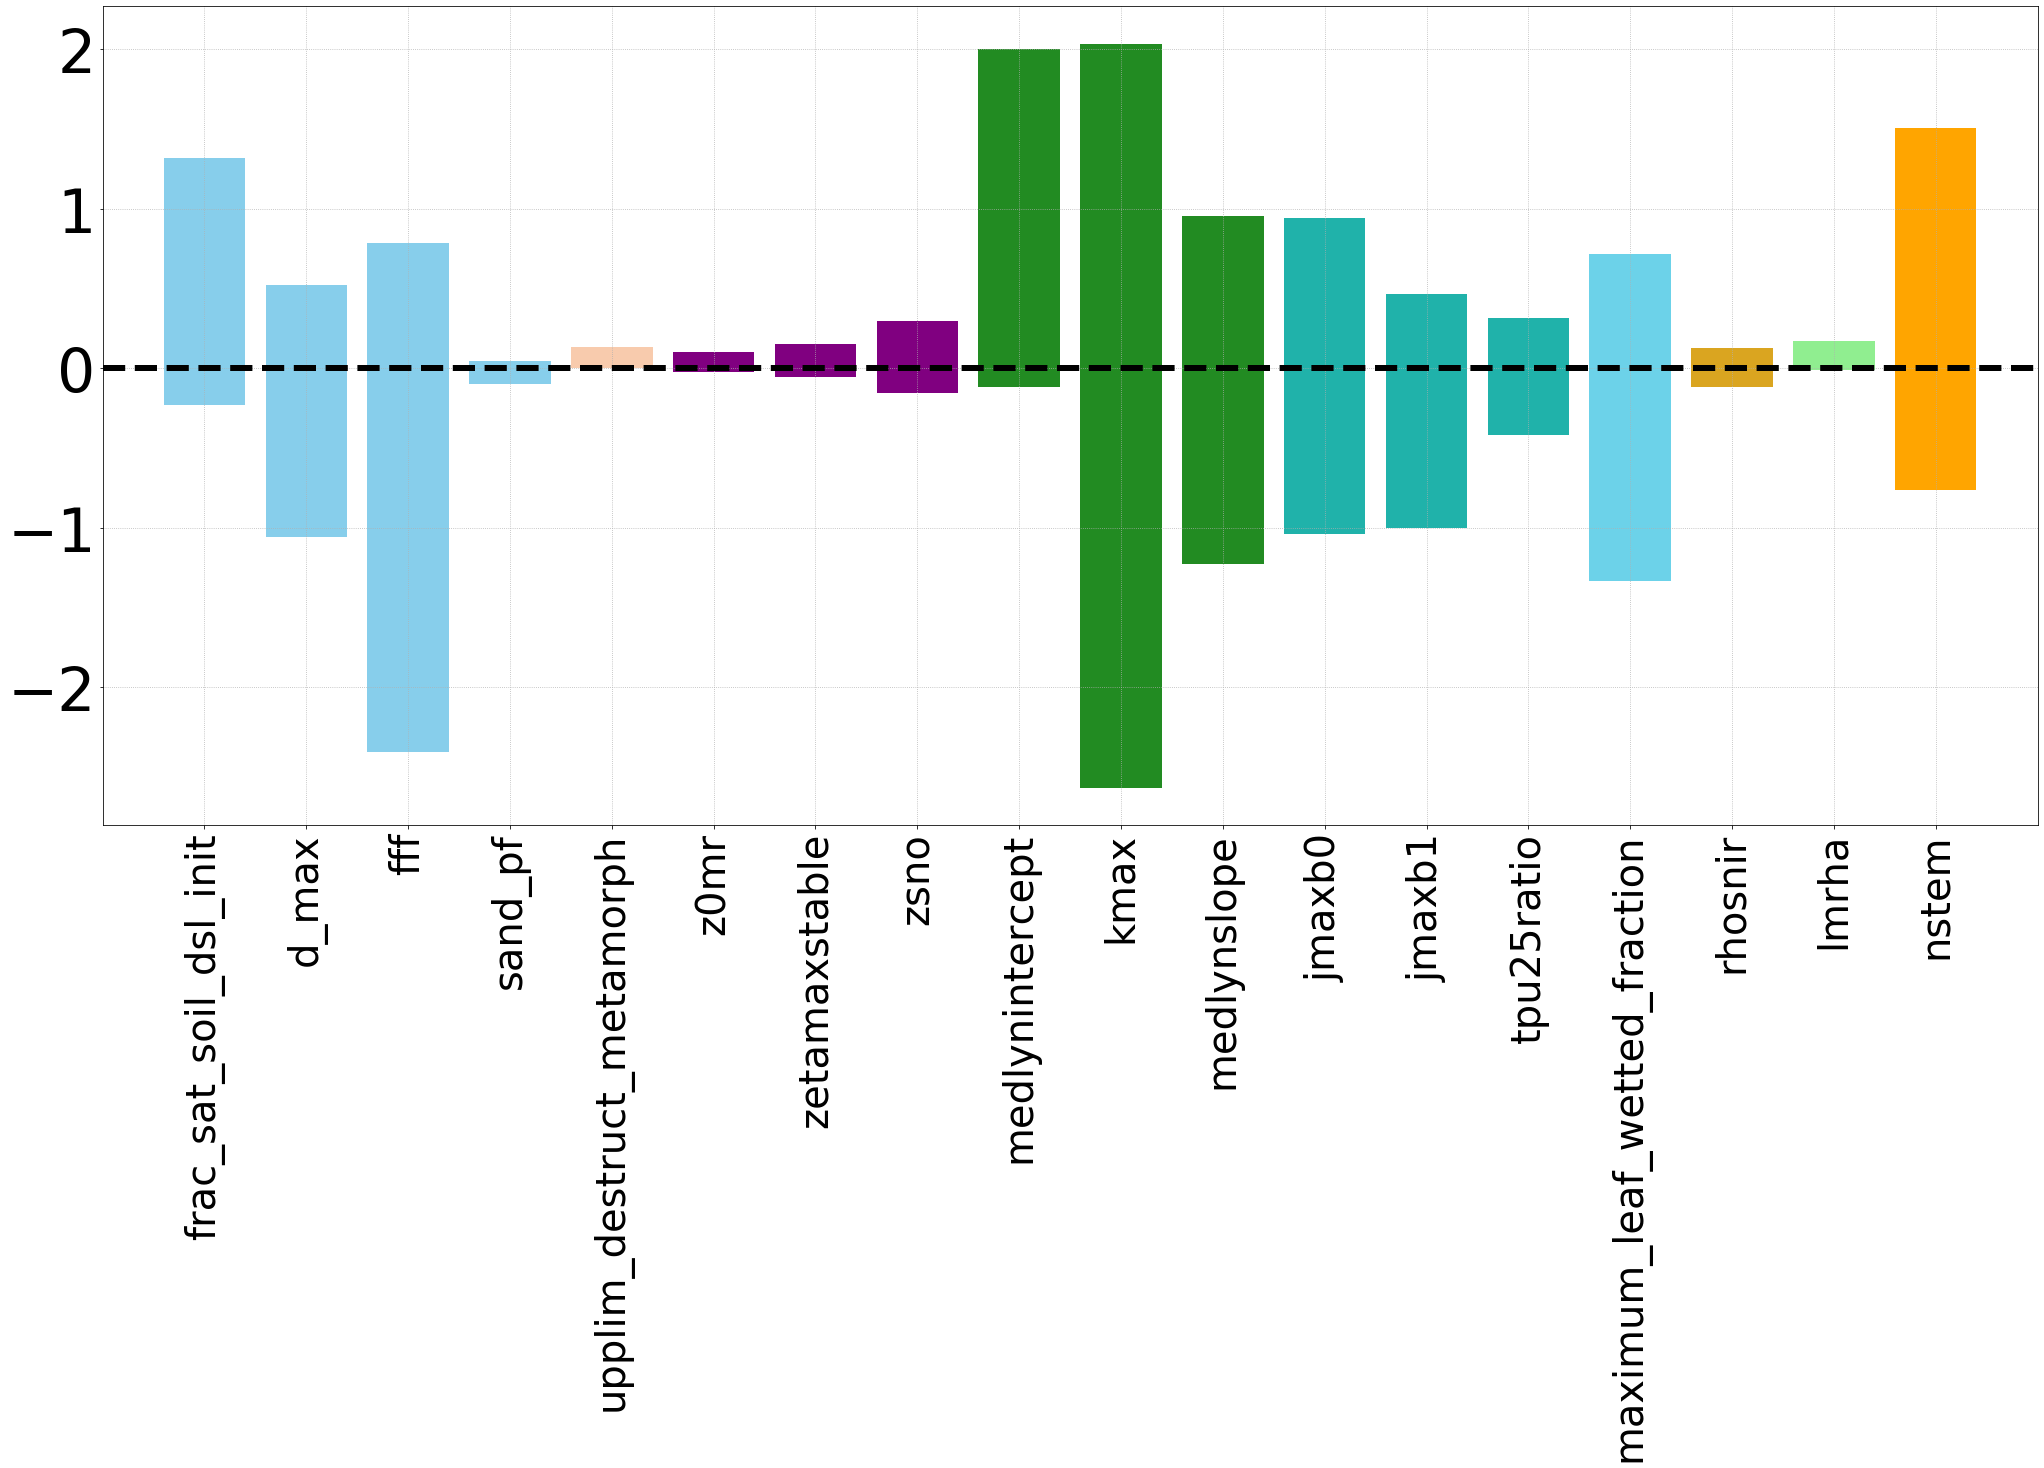

In [27]:
plt.rcParams.update({'font.size': 60})
plt.figure(figsize=(30,22))
lwidth=6
plt.axhline(y=0,linestyle='--',color='k', linewidth=lwidth)

for i, param in enumerate(params):
    minval=crosswalk['PREC_mode0'].values[crosswalk.description==param+', min']
    maxval=crosswalk['PREC_mode0'].values[crosswalk.description==param+', max']
    plt.bar(i,minval, color=param_colors[i])
    plt.bar(i,maxval, color=param_colors[i])
    
    #minval_PC0=crosswalk['PC0'].values[crosswalk.description==param+', min']
    #maxval_PC0=crosswalk['PC0'].values[crosswalk.description==param+', max']
    #plt.plot([i,i], 
    #         [minval_PC0,maxval_PC0],'x', markersize=20,linewidth=8, color='k')
    
    

xticks=plt.xticks(np.arange(0, i+1), params, rotation='vertical',fontsize=40)
plt.grid(linestyle=':')
plt.xlim([-1,np.size(params)])
plt.tight_layout()
plt.savefig('../Figures/Figure3c.pdf')